In [1]:
from fastai.vision.all import *
path = untar_data(URLs.BIWI_HEAD_POSE)

<div><progress max="452316199" value="452321280"></progress> 100.00% [452321280/452316199 00:10&lt;00:00]</div>

In [2]:
Path.BASE_PATH = path
# tells Path to treat path as the root directory, so file paths can be displayed and handled relative to
# that location instead of always showing the full absolute path.

In [3]:
path.ls().sorted()

[Path('01'), Path('01.obj'), Path('02'), Path('02.obj'), Path('03'), Path('03.obj'), Path('04'), Path('04.obj'), Path('05'), Path('05.obj'), Path('06'), Path('06.obj'), Path('07'), Path('07.obj'), Path('08'), Path('08.obj'), Path('09'), Path('09.obj'), Path('10'), Path('10.obj'), Path('11'), Path('11.obj'), Path('12'), Path('12.obj'), Path('13'), Path('13.obj'), Path('14'), Path('14.obj'), Path('15'), Path('15.obj'), Path('16'), Path('16.obj'), Path('17'), Path('17.obj'), Path('18'), Path('18.obj'), Path('19'), Path('19.obj'), Path('20'), Path('20.obj'), Path('21'), Path('21.obj'), Path('22'), Path('22.obj'), Path('23'), Path('23.obj'), Path('24'), Path('24.obj'), Path('io_sample.cpp'), Path('readme.txt')]

In [4]:
(path/'01').ls().sorted()

(#1000) [Path('01/depth.cal'), Path('01/frame_00003_pose.txt'), Path('01/frame_00003_rgb.jpg'), Path('01/frame_00004_pose.txt'), Path('01/frame_00004_rgb.jpg'), Path('01/frame_00005_pose.txt'), Path('01/frame_00005_rgb.jpg'), Path('01/frame_00006_pose.txt'), Path('01/frame_00006_rgb.jpg'), Path('01/frame_00007_pose.txt'), Path('01/frame_00007_rgb.jpg'), Path('01/frame_00008_pose.txt'), Path('01/frame_00008_rgb.jpg'), Path('01/frame_00009_pose.txt'), Path('01/frame_00009_rgb.jpg'), Path('01/frame_00010_pose.txt'), Path('01/frame_00010_rgb.jpg'), Path('01/frame_00011_pose.txt'), Path('01/frame_00011_rgb.jpg'), Path('01/frame_00012_pose.txt'), Path('01/frame_00012_rgb.jpg'), Path('01/frame_00013_pose.txt'), Path('01/frame_00013_rgb.jpg'), Path('01/frame_00014_pose.txt'), Path('01/frame_00014_rgb.jpg'), Path('01/frame_00015_pose.txt'), Path('01/frame_00015_rgb.jpg'), Path('01/frame_00016_pose.txt'), Path('01/frame_00016_rgb.jpg'), Path('01/frame_00017_pose.txt'), Path('01/frame_00017_rgb.j

In [5]:
img_files = get_image_files(path)
def img2pose(x): return Path(f'{str(x)[:-7]}pose.txt')
img2pose(img_files[0])

Path('22/frame_00163_pose.txt')

In [6]:
im = PILImage.create(img_files[0])
im.shape

(480, 640)

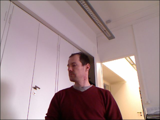

In [7]:
im.to_thumb(160)

In [8]:
cal = np.genfromtxt(path/'01'/'rgb.cal', skip_footer=6)
def get_ctr(f):
    ctr = np.genfromtxt(img2pose(f), skip_header=3)
    c1 = ctr[0] * cal[0][0]/ctr[2] + cal[0][2]
    c2 = ctr[1] * cal[1][1]/ctr[2] + cal[1][2]
    return tensor([c1,c2])

In [9]:
get_ctr(img_files[0])

tensor([311.6877, 268.2660])

In [10]:

biwi = DataBlock(
    blocks=(ImageBlock, PointBlock),
    get_items=get_image_files,
    get_y=get_ctr,
    splitter=FuncSplitter(lambda o: o.parent.name=='13'),
    batch_tfms=aug_transforms(size=(240,320)), 
)

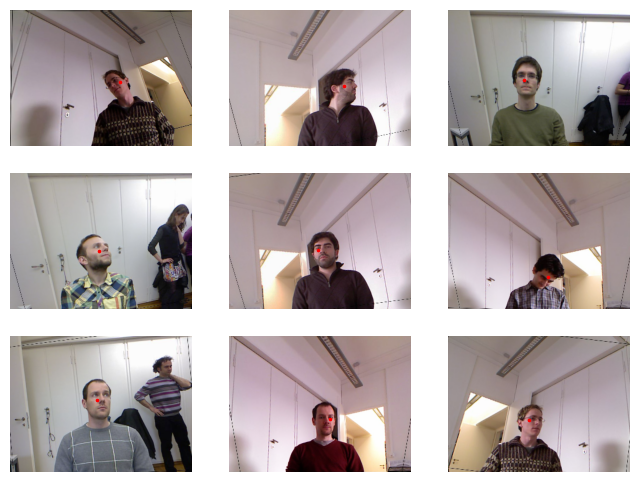

In [11]:
dls = biwi.dataloaders(path)
dls.show_batch(max_n=9, figsize=(8,6))

In [12]:

xb,yb = dls.one_batch()
xb.shape,yb.shape

(torch.Size([64, 3, 240, 320]), torch.Size([64, 1, 2]))

In [13]:
yb[0]

TensorPoint([[-0.1512,  0.3827]], device='cuda:0')

Training Model

In [14]:
# y_range=(-1,1) tells fastai to constrain the model's final predictions to
# the range -1 to 1, matching the normalized coordinate values thatthe network is trying to predict.

learn = vision_learner(dls, resnet18, y_range=(-1,1))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


In [15]:

def sigmoid_range(x, lo, hi): return torch.sigmoid(x) * (hi-lo) + lo

In [18]:
import fastai
import torch

print(fastai.__version__)
print(torch.__version__)

2.8.7
2.10.0+cu128


In [19]:
from fastai.vision.all import *

'plot_function' in globals()

False

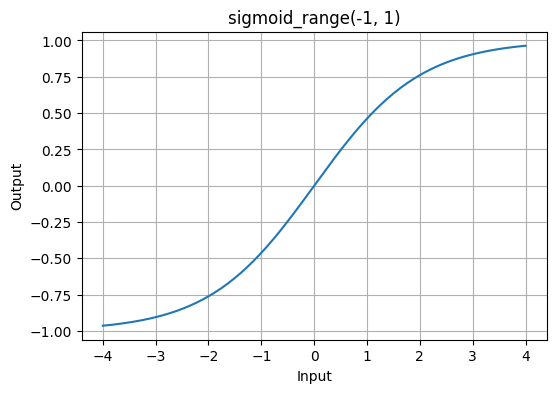

In [20]:
import torch
import matplotlib.pyplot as plt
from functools import partial

def sigmoid_range(x, lo, hi):
    return torch.sigmoid(x) * (hi-lo) + lo

x = torch.linspace(-4, 4, 200)
y = sigmoid_range(x, -1, 1)

plt.figure(figsize=(6,4))
plt.plot(x.numpy(), y.numpy())
plt.grid(True)
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("sigmoid_range(-1, 1)")
plt.show()

In [21]:
dls.loss_func

FlattenedLoss of MSELoss()

<div></div>

SuggestedLRs(valley=0.002511886414140463)

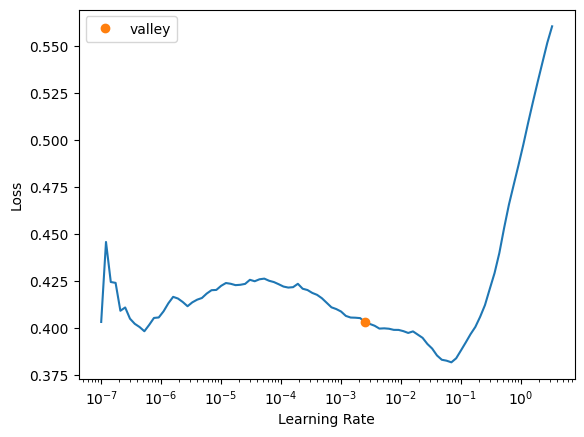

In [22]:
learn.lr_find()

In [23]:
lr = 1e-2
learn.fine_tune(3, lr)

epoch,train_loss,valid_loss,time
0,0.048451,0.010972,01:06


epoch,train_loss,valid_loss,time
0,0.007513,0.001993,01:23
1,0.002896,0.000100,01:23
2,0.001394,0.000247,01:23


In [24]:
math.sqrt(0.0001)

0.01

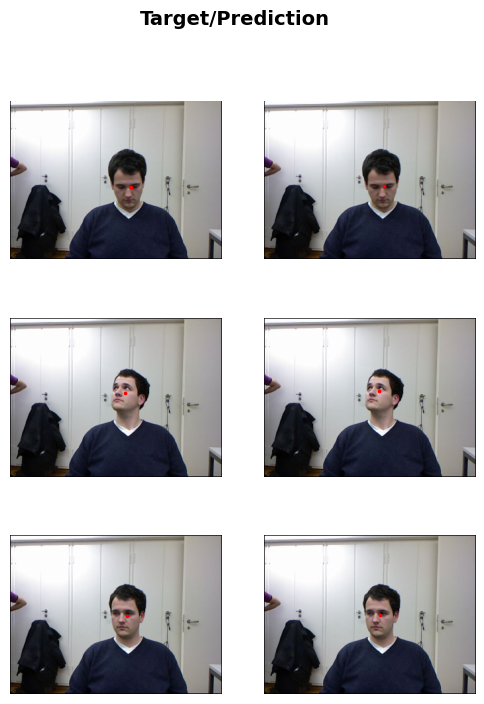

In [25]:
learn.show_results(ds_idx=1, nrows=3, figsize=(6,8))